Testing Composition Sequence: ['freq', 'color', 'spatial']
Files already downloaded and verified
Computing Flow Trajectories...

--- STABILITY CHECK ---
Theoretical Base Noise Norm: ~55.43
t=0.0 | ||u_t|| = 130.35
t=0.1 | ||u_t|| = 111.67
t=0.2 | ||u_t|| = 93.75
t=0.4 | ||u_t|| = 82.74
t=0.6 | ||u_t|| = 75.57
t=0.7 | ||u_t|| = 70.72
t=0.8 | ||u_t|| = 67.37
t=1.0 | ||u_t|| = 65.07


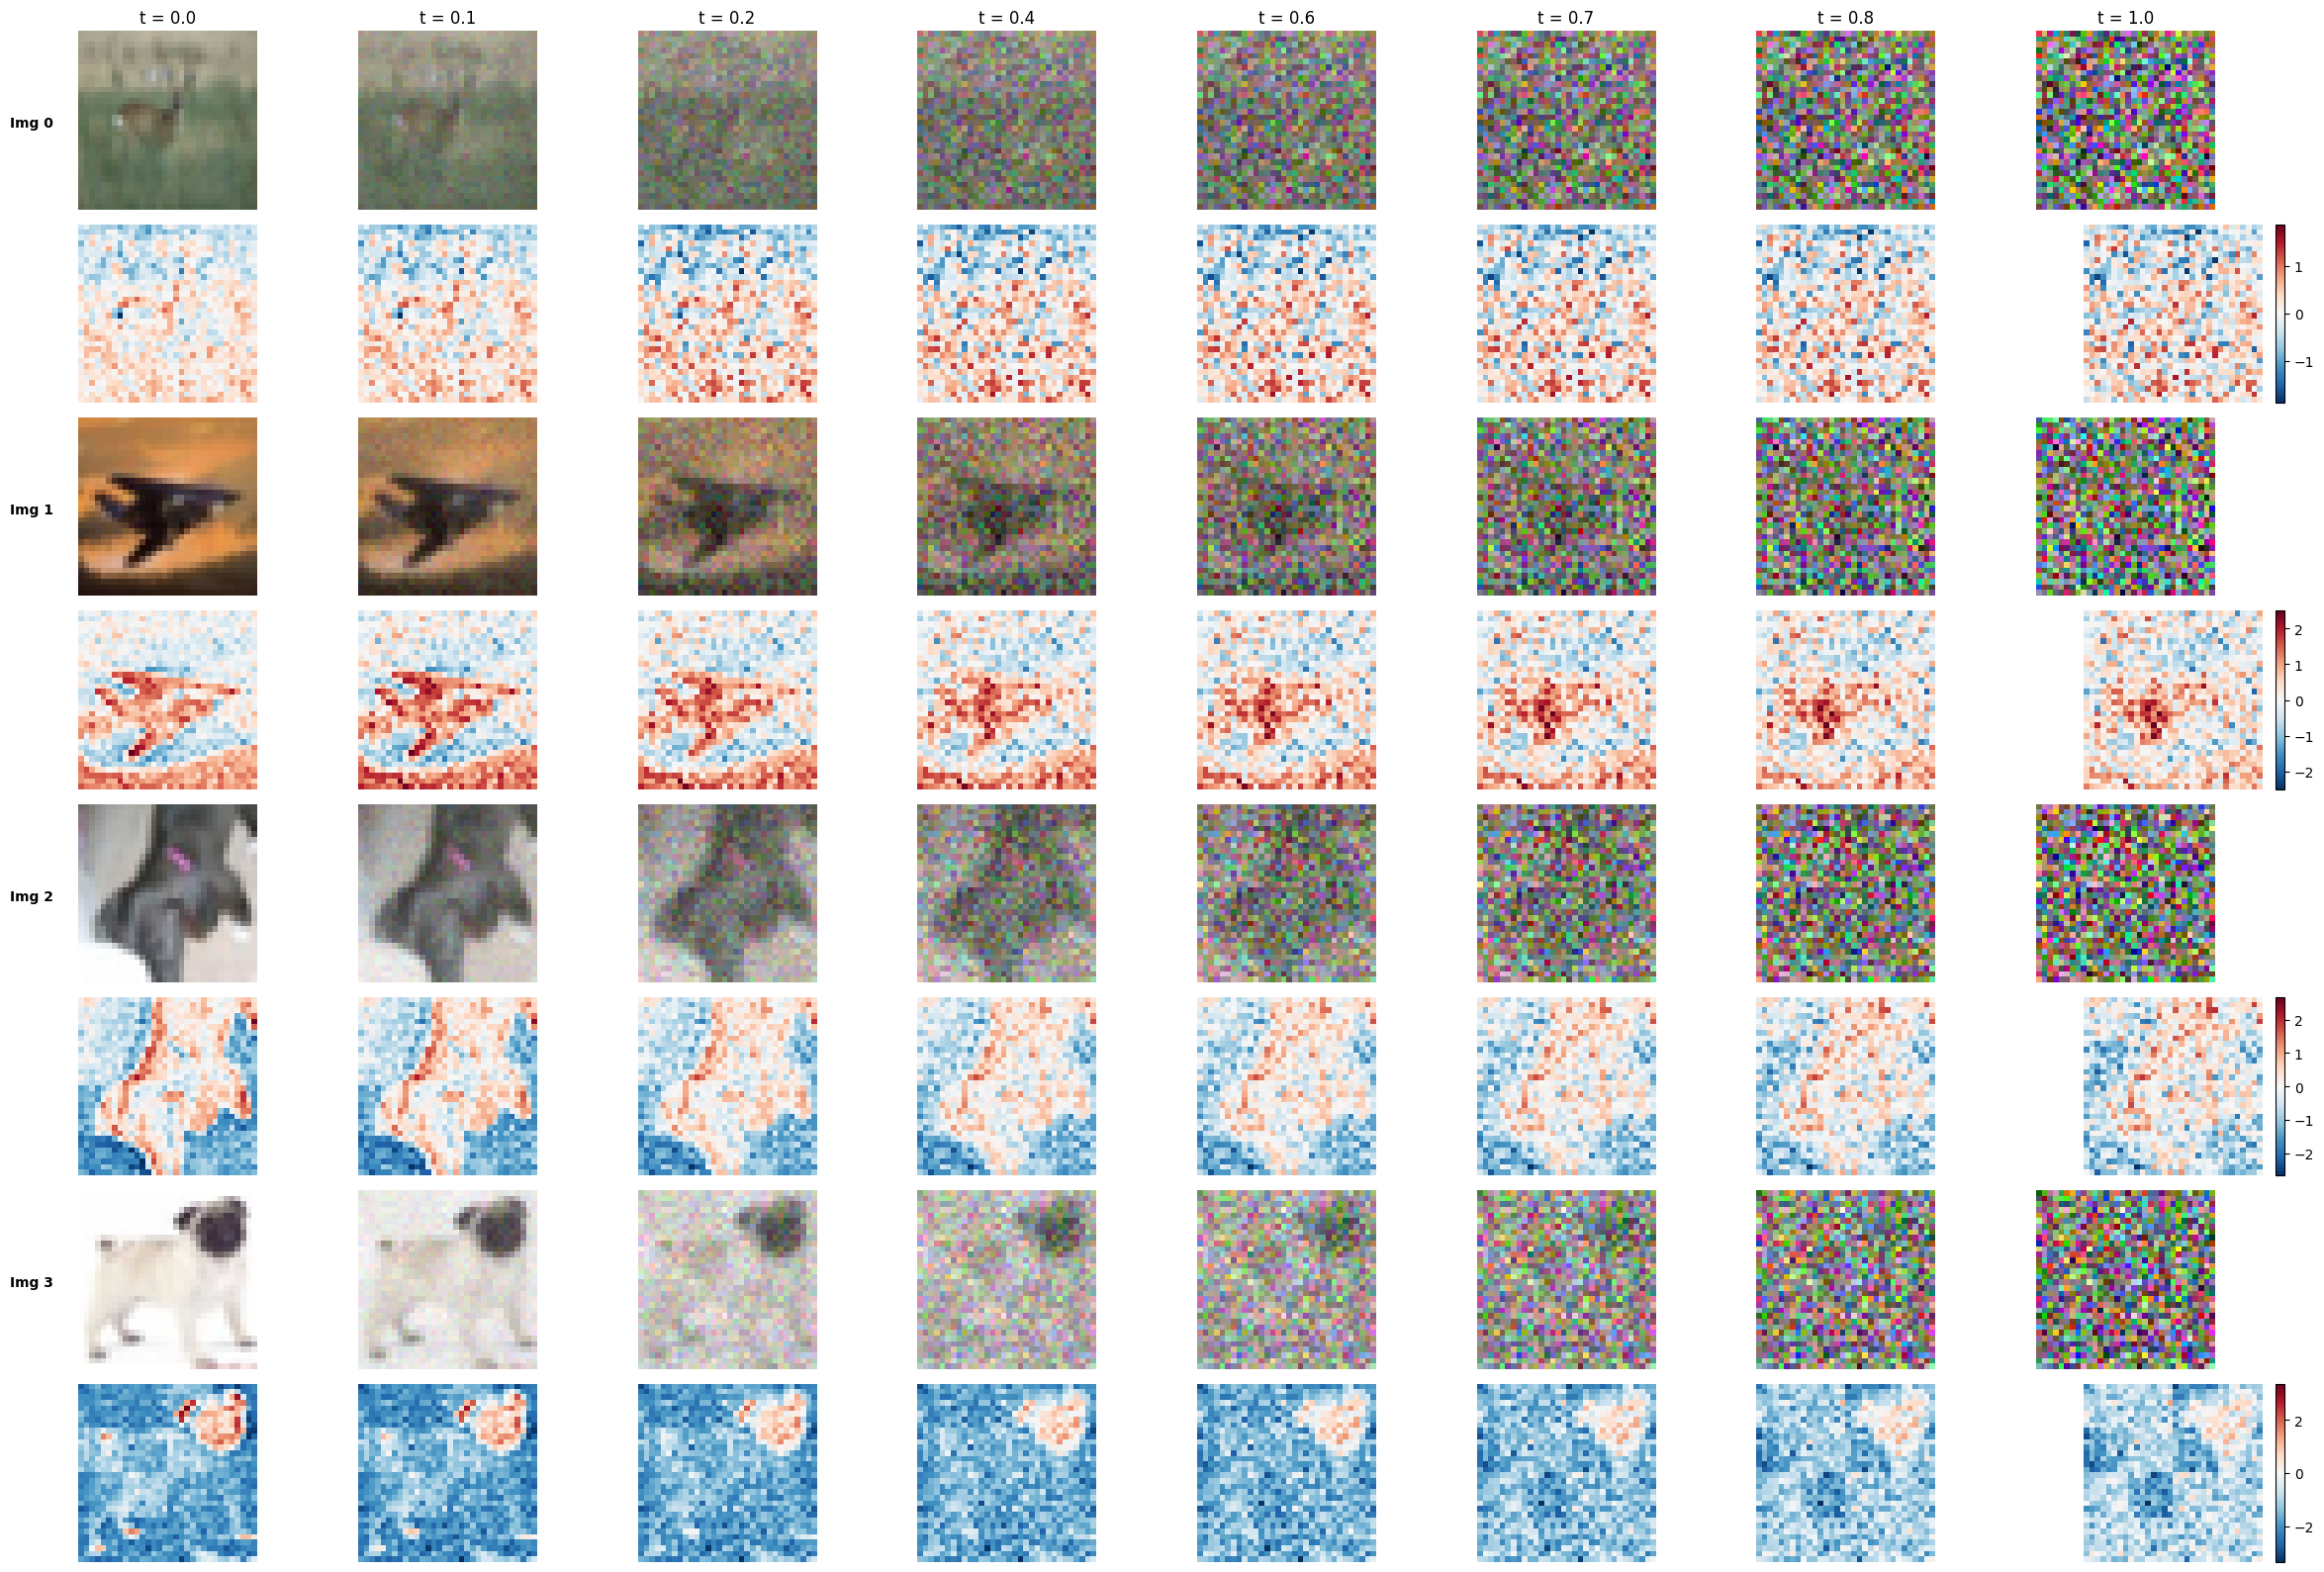

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure the parent directory is in the path
sys.path.append(os.path.abspath('..'))

# Import your refactored dynamic Flow Engine
from training.target_flow_lib import DecoupledOTCFM 

def unnormalize(tensor, stats):
    """Reverts Z-Score normalization for visualization."""
    mean = torch.tensor(stats['mean']).view(1, 3, 1, 1).to(tensor.device)
    std = torch.tensor(stats['std']).view(1, 3, 1, 1).to(tensor.device)
    x = tensor * std + mean
    return torch.clamp(x, 0, 1)

def run_flow_diagnostics():
    # 1. Experimental Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 4
    img_size = 32
    D = 3 * img_size * img_size
    
    test_operators = ['freq', 'color', 'spatial'] 
    
    k_base = 3.0
    k_beta = 0.5
    
    print(f"Testing Composition Sequence: {test_operators}")
    flow_engine = DecoupledOTCFM(img_shape=(3, img_size, img_size), 
                                device=device, 
                                operators=test_operators, 
                                k_base=k_base, k_beta = k_beta)

    # 2. Load Data (CIFAR-10)
    stats = {'mean': [0.4914, 0.4822, 0.4465], 'std': [0.2470, 0.2435, 0.2616]}
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(**stats)
    ])
    
    dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    real_batch, _ = next(iter(loader))
    real_batch = real_batch.to(device)
    
    # 3. Time Sweep
    time_steps = [0.0, 0.1, 0.25, 0.4, 0.55, 0.7,  0.85, 1.0]
    trajectory_x, trajectory_u, vel_norms = [], [], []
    
    print("Computing Flow Trajectories...")
    for t_val in time_steps:
        torch.manual_seed(42) # Fixed noise epsilon for path consistency
        t = torch.ones(batch_size, 1, 1, 1).to(device) * t_val
        
        with torch.no_grad():
            x_t, u_t = flow_engine.compute_target(real_batch, t)
            
        # Record metrics
        u_flat = u_t.reshape(batch_size, -1)
        vel_norms.append(torch.norm(u_flat, dim=1).mean().item())
        
        # Store for visualization
        trajectory_x.append(unnormalize(x_t, stats).cpu())
        trajectory_u.append(u_t.mean(dim=1).cpu()) # Mean across channels for heatmap

    # 4. Plotting Results
    print("\n--- STABILITY CHECK ---")
    print(f"Theoretical Base Noise Norm: ~{np.sqrt(D):.2f}")
    for i, t_val in enumerate(time_steps):
        print(f"t={t_val:.1f} | ||u_t|| = {vel_norms[i]:.2f}")

    fig, axes = plt.subplots(batch_size * 2, len(time_steps), figsize=(len(time_steps)*3, batch_size*4))
    
    for samp in range(batch_size):
        for col, t_val in enumerate(time_steps):
            # State Plot
            ax_x = axes[samp * 2, col]
            ax_x.imshow(trajectory_x[col][samp].permute(1, 2, 0).numpy())
            ax_x.axis('off')
            if samp == 0: ax_x.set_title(f"t = {t_val:.1f}")
            if col == 0: ax_x.text(-5, 16, f"Img {samp}", va='center', ha='right', weight='bold')

            # Velocity Heatmap Plot
            ax_u = axes[samp * 2 + 1, col]
            vel_map = trajectory_u[col][samp].numpy()
            max_val = max(abs(vel_map.max()), abs(vel_map.min())) + 1e-5
            im = ax_u.imshow(vel_map, cmap='RdBu_r', vmin=-max_val, vmax=max_val)
            ax_u.axis('off')
            if col == len(time_steps)-1:
                plt.colorbar(im, ax=ax_u, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_flow_diagnostics()

Testing Composition Sequence: ['freq', 'color', 'spatial']
Files already downloaded and verified
Computing Flow Trajectories...

--- STABILITY CHECK ---
Theoretical Base Noise Norm: ~55.43
t=0.0 | ||u_t|| = 130.35 | Var(Pc) = 1.17 | Var(Ps) = 0.04
t=0.1 | ||u_t|| = 111.67 | Var(Pc) = 0.82 | Var(Ps) = 0.03
t=0.2 | ||u_t|| = 93.75 | Var(Pc) = 0.48 | Var(Ps) = 0.06
t=0.4 | ||u_t|| = 82.74 | Var(Pc) = 0.27 | Var(Ps) = 0.13
t=0.6 | ||u_t|| = 75.57 | Var(Pc) = 0.15 | Var(Ps) = 0.24
t=0.7 | ||u_t|| = 70.72 | Var(Pc) = 0.08 | Var(Ps) = 0.39
t=0.8 | ||u_t|| = 67.37 | Var(Pc) = 0.06 | Var(Ps) = 0.58
t=1.0 | ||u_t|| = 65.07 | Var(Pc) = 0.07 | Var(Ps) = 0.80


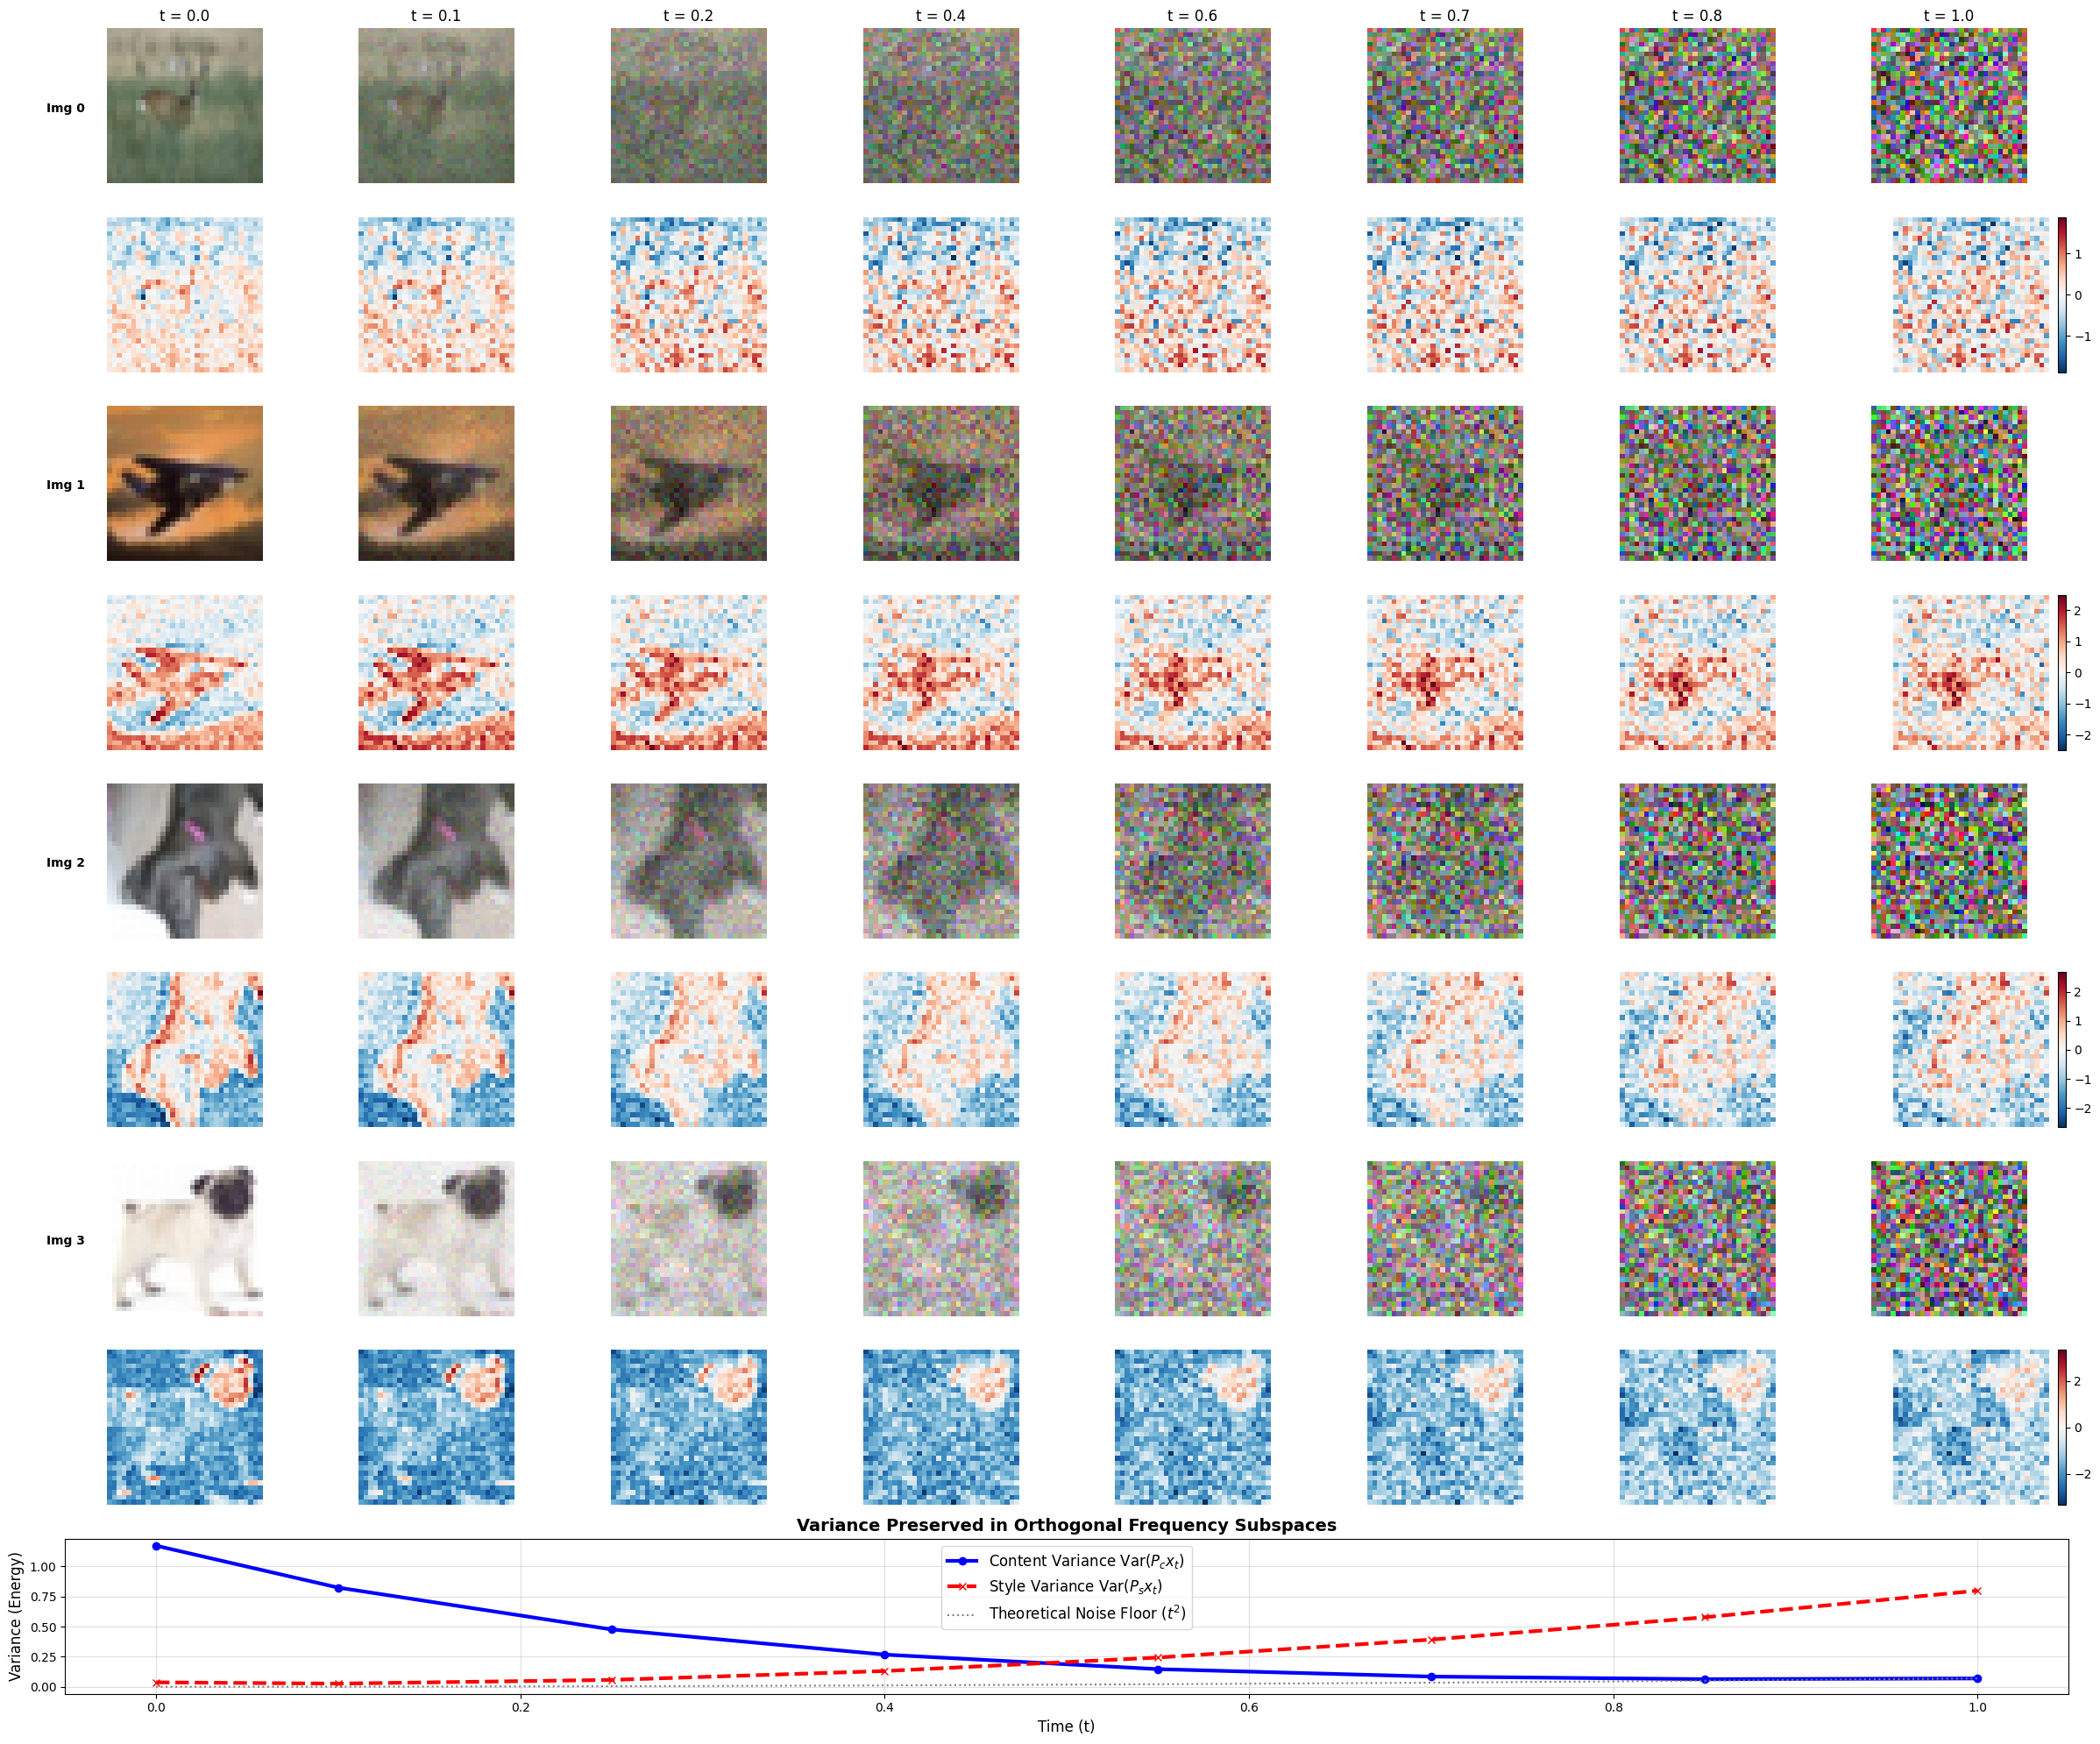

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure the parent directory is in the path
sys.path.append(os.path.abspath('..'))

from training.target_flow_lib import DecoupledOTCFM 

def unnormalize(tensor, stats):
    """Reverts Z-Score normalization for visualization."""
    mean = torch.tensor(stats['mean']).view(1, 3, 1, 1).to(tensor.device)
    std = torch.tensor(stats['std']).view(1, 3, 1, 1).to(tensor.device)
    x = tensor * std + mean
    return torch.clamp(x, 0, 1)

def run_flow_diagnostics():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 4
    img_size = 32
    D = 3 * img_size * img_size
    
    test_operators = ['freq', 'color', 'spatial'] 
    k_base = 3.0
    k_beta = 0.5
    
    print(f"Testing Composition Sequence: {test_operators}")
    flow_engine = DecoupledOTCFM(img_shape=(3, img_size, img_size), 
                                device=device, 
                                operators=test_operators, 
                                k_base=k_base, k_beta=k_beta)

    stats = {'mean': [0.4914, 0.4822, 0.4465], 'std': [0.2470, 0.2435, 0.2616]}
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(**stats)
    ])
    
    dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    real_batch, _ = next(iter(loader))
    real_batch = real_batch.to(device)
    
    time_steps = [0.0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]
    trajectory_x, trajectory_u, vel_norms = [], [], []
    
    # --- NEW: Subspace Variance Trackers ---
    freq_content_vars = []
    freq_style_vars = []
    
    print("Computing Flow Trajectories...")
    for t_val in time_steps:
        torch.manual_seed(42) 
        t = torch.ones(batch_size, 1, 1, 1).to(device) * t_val
        
        with torch.no_grad():
            x_t, u_t = flow_engine.compute_target(real_batch, t)
            
            # 1. Transform the state into the Orthogonal Frequency Basis
            X_t_freq = flow_engine.dct(x_t)
            
            # 2. Project onto Content (Pc) and Style (Ps) subspaces
            # Using the exact masks defined in your flow engine
            X_t_content = X_t_freq * flow_engine.freq_P_c
            X_t_style = X_t_freq * flow_engine.freq_P_s
            
            # 3. Compute Energy (Variance) per pixel
            var_c = X_t_content.pow(2).mean().item()
            var_s = X_t_style.pow(2).mean().item()
            
            freq_content_vars.append(var_c)
            freq_style_vars.append(var_s)
            # ---------------------------------------------------------
            
        u_flat = u_t.reshape(batch_size, -1)
        vel_norms.append(torch.norm(u_flat, dim=1).mean().item())
        
        trajectory_x.append(unnormalize(x_t, stats).cpu())
        trajectory_u.append(u_t.mean(dim=1).cpu())

    print("\n--- STABILITY CHECK ---")
    print(f"Theoretical Base Noise Norm: ~{np.sqrt(D):.2f}")
    for i, t_val in enumerate(time_steps):
        print(f"t={t_val:.1f} | ||u_t|| = {vel_norms[i]:.2f} | Var(Pc) = {freq_content_vars[i]:.2f} | Var(Ps) = {freq_style_vars[i]:.2f}")

    # 4. Plotting Results
    # Added an extra row for the Variance Plot
    fig = plt.figure(figsize=(len(time_steps)*3, batch_size*4 + 4))
    
    # Create a GridSpec to handle the layout
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(batch_size * 2 + 1, len(time_steps), figure=fig)
    
    # Plot Images and Heatmaps
    for samp in range(batch_size):
        for col, t_val in enumerate(time_steps):
            ax_x = fig.add_subplot(gs[samp * 2, col])
            ax_x.imshow(trajectory_x[col][samp].permute(1, 2, 0).numpy())
            ax_x.axis('off')
            if samp == 0: ax_x.set_title(f"t = {t_val:.1f}")
            if col == 0: ax_x.text(-5, 16, f"Img {samp}", va='center', ha='right', weight='bold')

            ax_u = fig.add_subplot(gs[samp * 2 + 1, col])
            vel_map = trajectory_u[col][samp].numpy()
            max_val = max(abs(vel_map.max()), abs(vel_map.min())) + 1e-5
            im = ax_u.imshow(vel_map, cmap='RdBu_r', vmin=-max_val, vmax=max_val)
            ax_u.axis('off')
            if col == len(time_steps)-1:
                plt.colorbar(im, ax=ax_u, fraction=0.046, pad=0.04)

    # --- NEW: Plot the Subspace Variance Trajectories ---
    ax_var = fig.add_subplot(gs[-1, :]) # Span the entire bottom row
    ax_var.plot(time_steps, freq_content_vars, label='Content Variance Var($P_c x_t$)', color='blue', linewidth=3, marker='o')
    ax_var.plot(time_steps, freq_style_vars, label='Style Variance Var($P_s x_t$)', color='red', linewidth=3, linestyle='--', marker='x')
    
    # Theoretical Noise Floor Plotting
    # Noise variance grows as t^2. Since P_c and P_s partition the space, the noise splits roughly proportionally.
    t_sq = np.array(time_steps)**2
    ax_var.plot(time_steps, t_sq * freq_content_vars[-1], color='gray', linestyle=':', label='Theoretical Noise Floor ($t^2$)')

    ax_var.set_title("Variance Preserved in Orthogonal Frequency Subspaces", fontsize=14, fontweight='bold')
    ax_var.set_xlabel("Time (t)", fontsize=12)
    ax_var.set_ylabel("Variance (Energy)", fontsize=12)
    ax_var.grid(True, alpha=0.4)
    ax_var.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_flow_diagnostics()